🧱 EXECUTIVE SUMMARY

This project analyzes the Brazilian E-commerce Public Dataset from Olist to understand marketplace performance, customer purchasing behavior, and order fulfillment efficiency across Brazil. The analysis integrates multiple transactional datasets—including orders, customers, payments, products, sellers, logistics, and reviews—into a consolidated analytical model suitable for business intelligence reporting.

Data preparation involved cleaning and transforming the data, addressing missing values, standardizing date formats, aggregating item-level transactions into order-level metrics, and engineering key variables such as total order value and delivery time. The prepared dataset was then used to develop an interactive Power BI dashboard for exploratory and operational analysis.

The dashboard highlights important patterns in order activity, customer satisfaction, delivery performance, order composition, and payment preferences. Overall, results suggest that customer satisfaction is generally high, but delivery delays can negatively influence review scores. Orders tend to contain a small number of items, indicating targeted purchasing behaviour, while credit-based payment methods dominate transactions.

These insights provide a foundation for improving operational efficiency, enhancing customer experience, and supporting data-driven decision-making within an e-commerce marketplace environment.


Dataset
The dataset is composed of several relational tables that represent different components of the e-commerce process, including orders, customers, order items, payments, products, sellers, geolocation, and customer reviews. These tables were integrated using common identifiers such as order_id and customer_id to build a consolidated analytical dataset suitable for exploratory data analysis.


🎯 OBJECTIVE

The objective of this notebook is to **clean, transform, and integrate multiple tables from the Olist e-commerce dataset to create a unified, order-level master dataset ready for Exploratory Data Analysis (EDA).** This preparation ensures the data is structured, consistent, and suitable for analyzing sales performance, customer behavior, and delivery efficiency.


🎯Introduction

This project analyzes the Brazilian Olist E-commerce public dataset to understand sales trends, customer purchasing behaviour, and delivery performance across Brazil.

The analysis includes:
- Data cleaning and preprocessing
- Exploratory data analysis (EDA)
- Feature creation
- Business insight generation
- Power BI dashboard development

The goal is to extract actionable insights from transactional marketplace data.

🎯Dataset Description

The dataset contains Brazilian e-commerce transactional data including:

- Customers
- Orders
- Order items
- Payments
- Products
- Sellers
- Customer reviews
- Geolocation data

Dataset Source:
Brazilian E-Commerce Public Dataset by Olist
https://www./kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce



🧱 STEP 1 — IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

📂 STEP 2 — LOAD ALL REQUIRED TABLES

In [2]:
orders = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
order_items = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')
customers = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')
payments = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv')
reviews = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv')
products = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv')
product_category = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv')

📂 STEP 3 — DATA INSPECTION

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
order_items.head(2)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93


In [6]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [7]:
products.head(2)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0


In [8]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [9]:
product_category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [10]:
product_category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [11]:
customers.head(2)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


In [12]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [13]:
payments.head(2)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39


In [14]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [15]:
reviews.head(2)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13


In [16]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


🧹 STEP 4 — PRE-CLEAN BEFORE MERGING

Convert Dates

This code ensures that all relevant order date columns are converted into **datetime format**, enabling accurate time-based analysis such as calculating delivery duration, identifying order trends over time, and comparing actual vs estimated delivery dates.


In [17]:
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

📦 STEP 5 — AGGREGATE ORDER ITEMS

Multiple rows per order to be aggregated.

This code summarizes item-level data into **order-level metrics**, calculating the total price, total freight cost, and number of items for each order. This allows the dataset to represent **one row per order**, making it suitable for merging with the main orders table and analyzing overall order value.


In [18]:
items_agg = order_items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    total_items=('order_item_id', 'count')
).reset_index()

STEP 6 — AGGREGATE PRODUCT CATEGORY

This converts item-level category data into order-level category data.

In [19]:
category_agg = (
    order_items
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .groupby('order_id')
    .agg(product_categories=('product_category_name', lambda x: ', '.join(x.dropna().unique())))
    .reset_index()
)

This aggregates all product categories purchased within the same order into a single column.

💳 STEP 7 — AGGREGATE PAYMENTS

Orders may have multiple payments. Combine unique payment types used in each order into a single comma-separated string

In [20]:
payments_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_types=('payment_type', lambda x: ', '.join(x.unique()))
).reset_index()

⭐ STEP 8 — HANDLE REVIEWS

In [21]:
reviews_sorted = reviews.sort_values('review_creation_date')
reviews_clean = reviews_sorted.drop_duplicates('order_id', keep='last')

🧩 STEP 8 — MERGE FLOW (CRITICAL ORDER)

The datasets are merged sequentially with **`orders` as the base table** to maintain one row per order.
Aggregated and cleaned tables are then joined to enrich the dataset with **item, payment, review, and customer information** without creating duplicate records.


We merge in this order:
orders
→ items_agg
→ payments_agg
→ reviews_clean
→ customers

1️⃣ Orders + Items

In [22]:
df_master = orders.merge(items_agg, on='order_id', how='left')

In [23]:
df_master["total_order_value"] = items_agg["total_price"] + items_agg["total_freight"]

2️⃣ Add Product Category

Merge Product Categories into Master Dataset

In [24]:
df_master = df_master.merge(
    category_agg,
    on='order_id',
    how='left'
)

This enriches the master dataset with product category information, enabling category-based sales and demand analysis.

2️⃣ Add Payments

In [25]:
df_master = df_master.merge(payments_agg, on='order_id', how='left')

3️⃣ Add Reviews

In [26]:
df_master = df_master.merge(
    reviews_clean[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

4️⃣ Add Customers

In [27]:
df_master = df_master.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

🚚 STEP 9 — FEATURE ENGINEERING

This code calculates the **number of days taken to deliver each order**, creating a key logistics metric. 
It enables analysis of **delivery performance, shipping efficiency, and the relationship between delivery time and customer satisfaction.**


In [28]:
df_master['delivery_days'] = (
    df_master['order_delivered_customer_date'] -
    df_master['order_purchase_timestamp']
).dt.days

Order Year

In [29]:
df_master['order_year'] = df_master['order_purchase_timestamp'].dt.year

Order Month

In [30]:
df_master['order_month'] = df_master['order_purchase_timestamp'].dt.month

In [31]:
df_master['total_items'].value_counts().sort_index()

total_items
1.0     88863
2.0      7516
3.0      1322
4.0       505
5.0       204
6.0       198
7.0        22
8.0         8
9.0         3
10.0        8
11.0        4
12.0        5
13.0        1
14.0        2
15.0        2
20.0        2
21.0        1
Name: count, dtype: int64

🧼 STEP 10 — FINAL CLEAN CHECK

In [32]:
df_master['total_items'].value_counts().sort_index()

total_items
1.0     88863
2.0      7516
3.0      1322
4.0       505
5.0       204
6.0       198
7.0        22
8.0         8
9.0         3
10.0        8
11.0        4
12.0        5
13.0        1
14.0        2
15.0        2
20.0        2
21.0        1
Name: count, dtype: int64

In [33]:
df_master.info()
df_master.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   total_price                    98666 non-null  float64       
 9   total_freight                  98666 non-null  float64       
 10  total_items                    98666 non-null  float64       
 11  total_order_val

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
total_price                       775
total_freight                     775
total_items                       775
total_order_value                 775
product_categories                775
total_payment                       1
payment_types                       1
review_score                      768
customer_state                      0
delivery_days                    2965
order_year                          0
order_month                         0
dtype: int64

In [34]:
df_master.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,total_items,total_order_value,product_categories,total_payment,payment_types,review_score,customer_state,delivery_days,order_year,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,1.0,72.19,utilidades_domesticas,38.71,"credit_card, voucher",4.0,SP,8.0,2017,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,1.0,259.83,perfumaria,141.46,boleto,4.0,BA,13.0,2018,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,1.0,216.87,automotivo,179.12,credit_card,5.0,GO,9.0,2018,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,1.0,25.78,pet_shop,72.20,credit_card,5.0,RN,13.0,2017,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,1.0,218.04,papelaria,28.62,credit_card,5.0,SP,2.0,2018,2
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,147.90,27.36,1.0,34.59,automotivo,175.26,credit_card,4.0,PR,16.0,2017,7
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaT,2017-05-09,49.90,16.05,1.0,31.75,,65.95,credit_card,2.0,RS,NaN,2017,4
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,59.99,15.17,1.0,880.75,automotivo,75.16,credit_card,5.0,RJ,9.0,2017,5
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,19.90,16.05,1.0,157.60,moveis_decoracao,35.95,boleto,1.0,RS,9.0,2017,1
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,149.99,19.77,1.0,65.39,moveis_escritorio,169.76,"voucher, credit_card",5.0,SP,18.0,2017,7


STEP 11 — FINAL MISSING VALUE HANDLING

Missing values introduced during the merging process were handled based on business logic. Delivery-related fields were preserved where orders were not delivered, review scores were filled to indicate the absence of feedback, and aggregated item values were set to zero for orders without item records.

In [35]:
# Convert Date Columns with Missing Values, order_approved_at, order_delivered_carrier_date, since they may remain missing because some orders never reached those stages.

# Convert to datetime but keep NaN.


date_cols = ['order_approved_at','order_delivered_carrier_date']

for col in date_cols:
    df_master[col] = pd.to_datetime(df_master[col])

In [36]:
# Handle Delivery-Related Missing Values in order_delivered_customer_date, 
#delivery_days usually occur because orders were cancelled, returned, or not delivered yet.

# Hence, keep them as NaN but exclude them when analyzing delivery performance.


delivered_orders = df_master[df_master['order_status'] == 'delivered']

In [37]:
# Suggests the order did not contain identifiable product items to give a sound bisness meaning for the missing values in the product categories.
df_master['product_categories'] = df_master['product_categories'].fillna('No Item Record')

In [38]:
# Missing reviews mean customers did not leave feedback.
# 0 indicates no review submitted, which helps differentiate from low ratings.

df_master['review_score'] = df_master['review_score'].fillna(0)

In [39]:
# Only one record missing
df_master['payment_types'] = df_master['payment_types'].fillna('unknown')
df_master['total_payment'] = df_master['total_payment'].fillna(df_master['total_payment'].median())

In [40]:
# Missing values occur because some orders have no matching item records (often cancelled orders), 
#since Orders without items should logically have 0 price and 0 items.

df_master[['total_price','total_freight','total_items']] = df_master[
    ['total_price','total_freight','total_items']
].fillna(0)

In [41]:
##Reconfirm for missing values

df_master.info()
df_master.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   total_price                    99441 non-null  float64       
 9   total_freight                  99441 non-null  float64       
 10  total_items                    99441 non-null  float64       
 11  total_order_val

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
total_price                         0
total_freight                       0
total_items                         0
total_order_value                 775
product_categories                  0
total_payment                       0
payment_types                       0
review_score                        0
customer_state                      0
delivery_days                    2965
order_year                          0
order_month                         0
dtype: int64

After cleaning and merging the datasets, the remaining missing values correspond to orders that were not approved, shipped, or delivered. These were preserved as they represent genuine operational outcomes rather than data quality issues.

💾 STEP 12 — EXPORT CLEAN MASTER FILE

In [42]:
df_master.to_csv("olist_master_cleaned.csv", index=False)

In [43]:
import os
os.listdir("/kaggle/working")

['olist_master_cleaned.csv', '.virtual_documents']

Now you have a clean analytical dataset ready for:
KPI analysis
Pivot tables
Excel dashboard
Advanced EDA

💾 STEP 13 — EXPLORATORY DATA ANALYSIS

With the cleaned and integrated dataset, exploratory analysis was performed to examine order activity, 
delivery performance, customer feedback, and purchasing behaviour across the platform. This stage aims to identify patterns and relationships within the data that can provide insight into how the marketplace operates.

Monthly Order Trends (Sales Growth)

Purpose:
Understand how order volume changes over time and detect seasonality.

Text(0.5, 1.0, 'Monthly Order Volume')

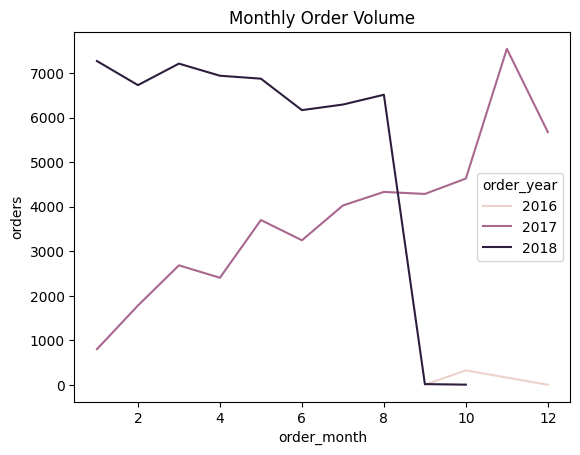

In [44]:
orders_by_month = df_master.groupby(['order_year','order_month']).size().reset_index(name='orders')

sns.lineplot(data=orders_by_month, x='order_month', y='orders', hue='order_year')
plt.title("Monthly Order Volume")

Insight:
Shows growth patterns, seasonal peaks, and promotional effects. 

Top Product Categories by Revenue

 (Requires merging with product category data if available.)

 Purpose:
 Identify which product categories generate the most revenue.

Text(0.5, 1.0, 'Top States by Revenue')

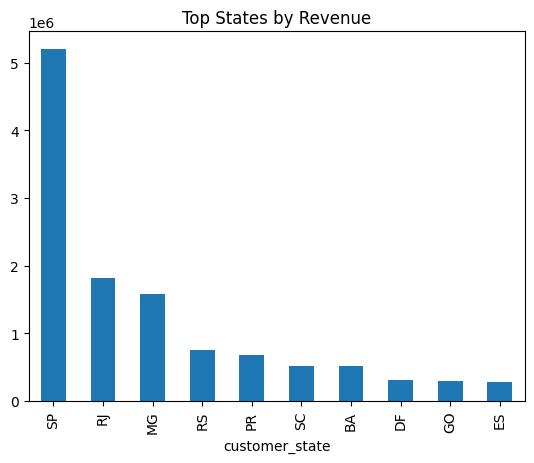

In [45]:
top_states = df_master.groupby('customer_state')['total_price'].sum().sort_values(ascending=False).head(10)

top_states.plot(kind='bar')
plt.title("Top States by Revenue")

Insight:
Reveals geographic demand concentration. Orders are spread across a wide range of product categories, but a relatively small number of categories appear more frequently than others. This suggests that customer demand is concentrated in a few key product segments, which likely contribute a large share of the platform’s overall sales activity. São Paulo, Rio de Janeiro, Minas Gerais Brazilian states that dominate demand distribution.

Order Status Distribution

Purpose:
Understand the operational health of the marketplace.

Text(0.5, 1.0, 'Order Status Distribution')

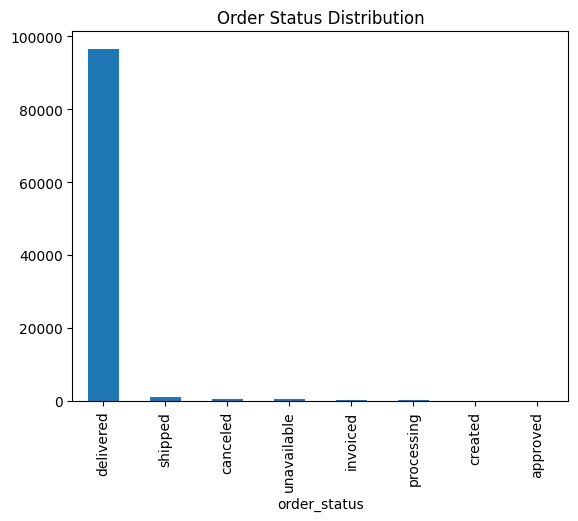

In [46]:
df_master['order_status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")

Insight:
Shows proportion of: delivered, cancelled, shipped, processing

Delivery Time Distribution

Purpose:
Evaluate logistics performance.

Text(0.5, 1.0, 'Delivery Time Distribution')

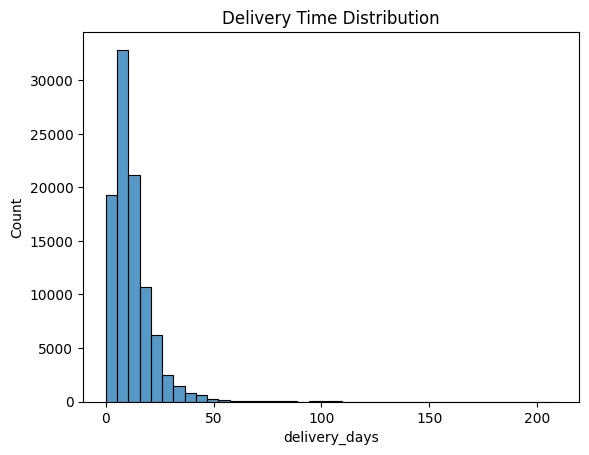

In [47]:
sns.histplot(df_master['delivery_days'].dropna(), bins=40)
plt.title("Delivery Time Distribution")

Insight:
Shows typical delivery duration and outliers.

Review Score Distribution

Purpose:
Measure customer satisfaction.

Text(0.5, 1.0, 'Customer Review Score Distribution')

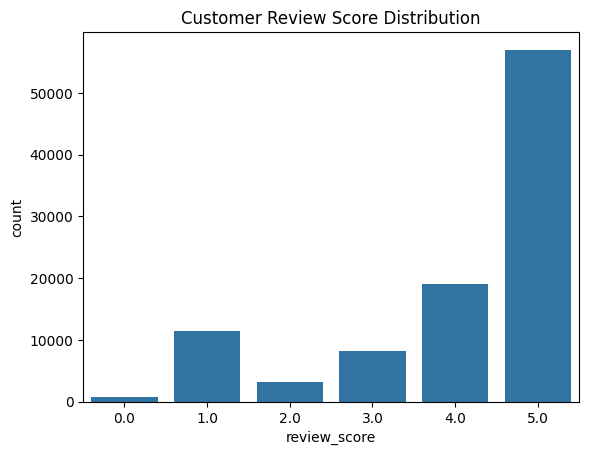

In [48]:
sns.countplot(x='review_score', data=df_master)
plt.title("Customer Review Score Distribution")

Insight:
Shows whether customers are generally satisfied or dissatisfied.

13.6 Delivery Time vs Review Score

Purpose:
Understand whether slow delivery affects customer ratings.

Text(0.5, 1.0, 'Delivery Time vs Customer Review')

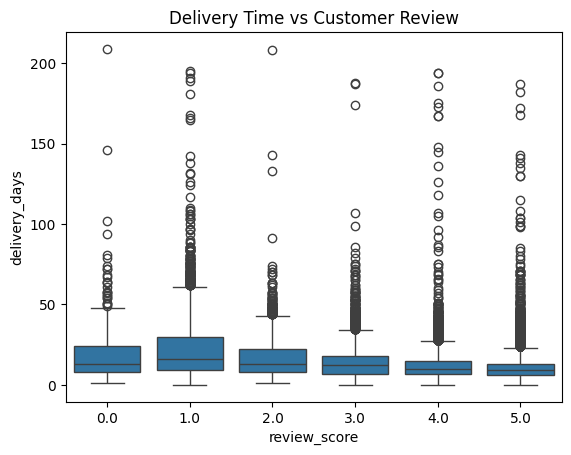

In [49]:
sns.boxplot(x='review_score', y='delivery_days', data=df_master)
plt.title("Delivery Time vs Customer Review")

Insight:
Often reveals that longer delivery times lead to lower review scores.

Payment Type Distribution

Text(0.5, 1.0, 'Payment Method Distribution')

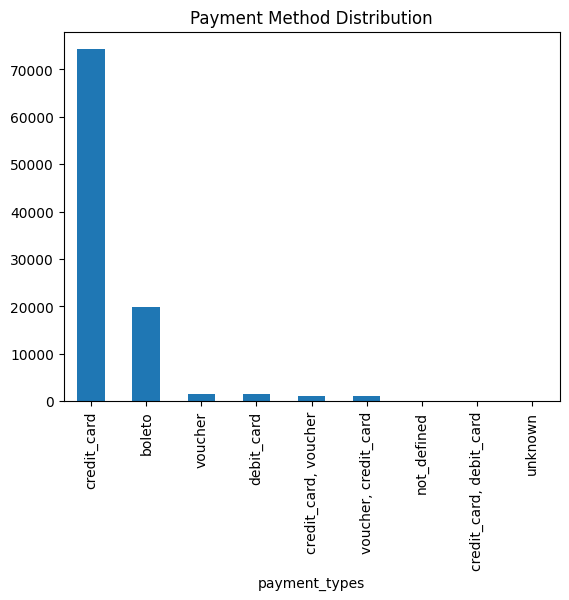

In [50]:
df_master['payment_types'].value_counts().plot(kind='bar')
plt.title("Payment Method Distribution")

Insight:
Shows dominant payment behaviour (credit card is usually the highest).

Feature Relationships Overview

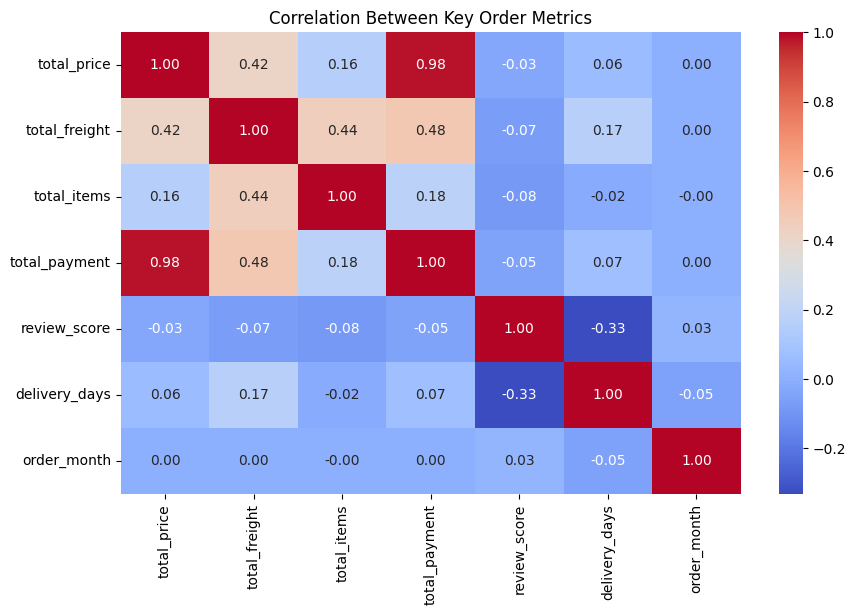

In [51]:
# Select numerical columns
num_cols = [
    'total_price',
    'total_freight',
    'total_items',
    'total_payment',
    'review_score',
    'delivery_days',
    'order_month'
]

# Compute correlation matrix
corr_matrix = df_master[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Key Order Metrics")
plt.show()

Insight: The correlation heatmap provides an overview of relationships between key numerical variables. As expected, the delivery time shows only a weak relationship with customer review scores. 

💾 STEP 14 — STRATEGIC INSIGHT

Order Volume Trend

Order activity shows noticeable variation across months, with some periods experiencing clear spikes in purchases. This likely reflects seasonal shopping behavior or promotional campaigns that temporarily increase or decreased demands in respective years.

Geographic Distribution

Orders are not evenly distributed across Brazil. A small number of states account for a large share of total purchases, suggesting that e-commerce adoption is stronger in more populated or economically active regions.

Delivery Performance

Most deliveries are completed within a relatively short timeframe, although a small portion of orders take significantly longer. These longer delivery times may be linked to geographic distance, logistics capacity, or regional infrastructure differences.

Customer Review Behavior

Customer ratings tend to cluster toward the higher end of the scale, indicating generally positive shopping experiences. However, lower ratings appear more frequently among orders that experienced longer delivery times.

Payment Behavior

Credit-based payments appear to dominate the platform. This suggests that instalment-based purchasing plays an important role in enabling customers to make larger or more frequent online purchases.

Order Composition

Many orders contain only one or two items, indicating that customers often make targeted purchases rather than large multi-product baskets.

💾 STEP 15 —BUSINESS INSIGHT

Order Activity
Order volume varies across months, suggesting that purchasing activity is influenced by seasonal demand and promotional periods. Some months show noticeably higher order counts compared with others.

Customer Satisfaction
Most review scores fall in the higher rating range, indicating generally positive customer experiences. Lower ratings appear more often in orders with longer delivery times, suggesting that delivery performance can influence customer feedback.

Delivery Performance
The majority of orders are delivered within a reasonable time frame. However, there are a small number of cases where delivery takes significantly longer, which may be related to distance, logistics constraints, or regional differences.

Order Size
Many orders consist of one or two items, showing that customers often make focused purchases rather than buying many products at once.

Payment Preferences
Credit-based payment methods appear to be widely used, which suggests that instalment or card-based purchasing is common among customers on the platform.

Order Value Patterns
Customers often make targeted purchases.

💾 STEP 16 — CONCLUSION

This notebook prepared and integrated several tables from the Olist dataset into a single order-level dataset for analysis. The exploratory analysis provides an overview of purchasing patterns, delivery performance, and customer satisfaction across the platform. Overall, the marketplace shows stable order activity and generally positive customer feedback, while delivery time remains an important factor that can influence customer reviews.

## Project Repository

GitHub Repository:
https://github.com/chinthakagama/olist-eda-powerbi-dashboard-ecommerce-data-cleaning-analysis

Power BI Dashboard:
Available in the GitHub repository.